# Snx17 comparison: two independent equilibration → assay runs

Keep this notebook and your existing `ode_parameters.yaml` together. Start Jupyter in that folder; install PyYAML with `%pip install pyyaml` if needed. **Restart Kernel and Run All** after changing parameters.

The two pairs below override only equilibration Snx17 (0 or 300 nM). Each assay starts from its own complete equilibrated state and adds the configured assay proteins without dilution. This replaces the old positive-value overwrite loop, which could discard additions. ODE equations and YAML rate settings are unchanged.

Execution, analysis, and plotting have separate cells. Re-running a plot does not re-run either model. The original experimental CSV overlay is optional and is not used to calculate simulation AUCs.

**AUC definition:** trapezoidal integration over the same configured assay interval, excluding equilibration. The primary curve is the original normalised probe-signal loss, `1 - PbA(t)/max(PbA)` (maximum calculated separately within each assay). AUC units are seconds. **AUCR = AUC at 300 nM / AUC at 0 nM**. Values above 1 mean greater integrated probe-signal loss, not greater remaining probe. Raw PI(3)P, raw bound probe, and normalised PI(3)P depletion are also compared, since their ratios answer different questions. These are finite-window model comparisons, not drug-exposure AUCRs.

## 1. Imports

In [1]:
import sys
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
import csv

# S = Snx17
# M = MTM1
# P = ProbeN
# A = Pi3P
# B = Pi
# C = Cargo

## 2. Load YAML parameters

In [2]:
from pathlib import Path
import yaml

# Keep the YAML beside this notebook and start Jupyter in that folder.
# If needed, replace this with the full path to your YAML file.
CONFIG_PATH = Path("ode_parameters.yaml").resolve()
with CONFIG_PATH.open(encoding="utf-8") as f:
    config = yaml.safe_load(f)

affinities = config["affinities"]
Volume = config["geometry"]["Volume"]
TotalMembraneSA = config["geometry"]["TotalMembraneSA"]

keff_M = config["catalysis"]["keff_M"]
keff_SM = config["catalysis"]["keff_SM"]
keff_MM = config["catalysis"]["keff_MM"]
if keff_SM is None:
    keff_SM = keff_M
if keff_MM is None:
    keff_MM = keff_M

params = dict(config["association_rates"])
ref = config["dissociation_reference"]
for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                        ("PA", "Kd_PA"), ("PB", "Kd_PB"),
                        ("MMf", "Kd_MM_3D")]:
    reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
    params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])
for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC"), ("MMa", "Kd_MM_2D")]:
    params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])

divisors = config["complex_off_rate_divisors"]
params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
params["koff_MAM"] = params["koff_MA"] / divisors["MAM"]
params.update(keff_M=keff_M, keff_SM=keff_SM, keff_MM=keff_MM,
              ka=config["transport"]["ka"])

eq_Snx17_conc = config["equilibration"]["Snx17_conc"]
eq_MTM1_conc = config["equilibration"]["MTM1_conc"]
eq_Probe_conc = config["equilibration"]["Probe_conc"]
eq_cargo_conc = config["equilibration"]["cargo_fraction"]
PC_concentration = config["membrane"]["PC_concentration"]
membrane_substrate = config["membrane"]["membrane_substrate"]
membrane_product = config["membrane"]["membrane_product"]
equilibration_time = config["equilibration"]["time_s"]
initial_Snx17_conc = config["assay"]["Snx17_conc"]
initial_MTM1_conc = config["assay"]["MTM1_conc"]
initial_Probe_conc = config["assay"]["Probe_conc"]
simulation_time = config["assay"]["time_s"]
solver_options = dict(config["solver"])
file_settings = config["files"]
experimental_csv = CONFIG_PATH.parent / file_settings["experimental_csv"]
results_csv = CONFIG_PATH.parent / file_settings["results_csv"]

## 3. Initial-state template and unchanged ODE

In [3]:
equilibration_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    eq_Snx17_conc, # Sf
    eq_MTM1_conc, # Mf
    eq_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    0, # MMf
    0, # MMb
    PC_concentration * membrane_substrate, # A
    PC_concentration * membrane_product, # B
    PC_concentration * eq_cargo_conc # C
]

# ===================== ODE Model =====================

def change_in_bidning(kon, substrate,
                      koff, free_form, bound_form):
    
    return kon * substrate * free_form - koff * bound_form

#trajectory_arrays = []
def model(t, y, parameter_values=None, volume_um3=None, area_um2=None):
    # Optional inputs let sensitivity runs use their own settings.
    p = params if parameter_values is None else parameter_values
    volume = Volume if volume_um3 is None else volume_um3
    area = TotalMembraneSA if area_um2 is None else area_um2
    Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, MMf, MMb, A, B, C = y

    kon_SA   = p["kon_SA"]
    koff_SA  = p["koff_SA"]
    kon_MA   = p["kon_MA"]
    koff_MA  = p["koff_MA"]
    kon_PA   = p["kon_PA"]
    koff_PA  = p["koff_PA"]
    kon_PB   = p["kon_PB"]
    koff_PB  = p["koff_PB"]
    kon_SM   = p["kon_SM"]
    koff_SM  = p["koff_SM"]
    koff_SAM = p["koff_SAM"]
    kon_SC   = p["kon_SC"]
    koff_SC  = p["koff_SC"]
    koff_SAC = p["koff_SAC"]
    kon_MMf = p["kon_MMf"]
    koff_MMf = p["koff_MMf"]
    kon_MMa = p["kon_MMa"]
    koff_MMa = p["koff_MMa"]
    kon_MAM = p["kon_MAM"]
    koff_MAM = p["koff_MAM"]
    keff_M   = p["keff_M"]
    keff_SM  = p["keff_SM"]
    keff_MM  = p["keff_MM"]
    ka       = p["ka"]

    # =================================== ODE equations
    # Free lipid/cargo available for binding
    A_bind = max((A - SbA - MbA - PbA - (SMb*2) - SbC - (MMb*2)), 0.0) # ensures that [Pi3P] can never fall below 0nM
    B_bind = max((B - PbB), 0.0) # ensures that [Pi] can never fall below 0nM
    C_bind = max((C - SbC), 0.0) # ensures that [Cargo] can never fall below 0nM

    
    # Convert nM to molecules/um2 for 2D binding calculations
    aMbA = ((MbA * 0.602) * volume) / area # molecules/um2 ([nM] * 0.602 = molecules per um3)
    aSbA = ((SbA * 0.602) * volume) / area # molecules/um2 
    aSMb = ((SMb * 0.602) * volume) / area # molecules/um2
    aC_bind = ((C_bind * 0.602) * volume) / area # molecules/um2
    aSbC = ((SbC * 0.602) * volume) / area # molecules/um2
    aMMb = ((MMb * 0.602) * volume) / area # molecules/um2

    # 2D reaction rates (molecules/um2/s)
    # S·A + M·A <-> SM (both membrane-bound)
    SMb_rate_mum2 = change_in_bidning(kon_SM, aMbA, koff_SM, aSbA, aSMb)
    
    # S·A + C <-> S·A·C  (S must already be membrane-bound via A)
    SbC_rate_mum2 = change_in_bidning(kon_SC, aC_bind, koff_SC, aSbA, aSbC)

    # M·A + M·A <-> MM (both membrane-bound)
    MMb_rate_mum2 = change_in_bidning(kon_MMa, aMbA, koff_MMa, aMbA, aMMb)
    
    # Convert 2D rates back to nM/s
    SMb_rate_nM = (SMb_rate_mum2 * area) / (0.602 * volume)
    SbC_rate_nM = (SbC_rate_mum2 * area) / (0.602 * volume)
    MMb_rate_nM = (MMb_rate_mum2 * area) / (0.602 * volume)

    
    # Diffusion from compartment 1 -> compartment 2
    dSa = -(ka * Sa)
    dMa = -(ka * Ma)
    dPa = -(ka * Pa)

    
    # Calculating state changes in compartment 2
    # Free S, M, and P
    dSf = -change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          (koff_SAC * SbC) + \
          (koff_SAM * SMb) + (ka * Sa)
    
    dMf = -change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          (koff_SAM * SMb) + (ka * Ma) + \
          (-change_in_bidning(kon_MMf, Mf, koff_MMf, Mf, MMf) * 2)
    
    dPf = -change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA) + \
          -change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB) + (ka * Pa)

    dMMf = change_in_bidning(kon_MMf, Mf, koff_MMf, Mf, MMf) + \
          -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb)
    #print(dMMf, -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb), kon_MAM, A_bind, koff_MAM, MMf, MMb)


    # Binding from compartment 2 -> compartment 3
    dSbA = change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          -SMb_rate_nM + \
          -SbC_rate_nM

    dMbA = change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          -SMb_rate_nM - (2 * MMb_rate_nM)
    
    dPbA = change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA)
    
    dPbB = change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB)

    
    # SAM complex
    dSMb = SMb_rate_nM -(koff_SAM * SMb)

    # SAC complex
    dSbC = SbC_rate_nM -(koff_SAC * SbC)

    # MAM complex
    dMMb = change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb) + MMb_rate_nM
    #print(dMMb)
    #print(dMMb, MMb_rate_nM, kon_MAM, A_bind, koff_MAM, MMf, MMb)

    # Catalysis: Pi3P -> Pi
    dB = (keff_M * MbA * A_bind) + (keff_SM * SMb * A_bind) + (keff_MM * 2 * MMb * A_bind)
    dA = -dB

    #trajectory_arrays.append([dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dA, dB])
    
    return [dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dMMf, dMMb, dA, dB, 0]

## 4. Common settings

In [4]:
label_list = ["[undelivered Snx17]", "[undelivered MTM1]", "[undelivered Pi3P Probe]", "[solution Snx17]", "[solution MTM1]", "[solution Pi3P Probe]",
              "[Pi3P-bound Snx17]", "[Pi3P-bound MTM1]", "[Pi3P-bound Pi3P Probe]", "[Pi-bound Pi3P Probe]", "[Pi3P-bound Snx17-MTM1]",
              "[Pi3P-bound Snx17-Cargo]", "[solution MTM1 Dimer]", "[Pi3P-bound MTM1 Dimer]", "[Pi3P]", "[Pi]", "[Cargo]"]
colour_list = ["grey", "grey", "grey", "cyan", "green", "olive", "blue", "gold",
              "orange", "purple", "fuchsia", "tan", "palegreen", "violet", "red", "plum", "thistle"]


# The same assay interval and rate settings are used for both scenarios.
# A signature catches a changed setup between either equilibration and assay.
def current_setup():
    import json
    return json.dumps({"params": params, "Volume": Volume,
                       "TotalMembraneSA": TotalMembraneSA,
                       "initial_template": equilibration_concentrations,
                       "equilibration_time": equilibration_time,
                       "simulation_time": simulation_time,
                       "solver": solver_options,
                       "assay_additions": [initial_Snx17_conc, initial_MTM1_conc,
                                           initial_Probe_conc]}, sort_keys=True)

if simulation_time[1] <= simulation_time[0]:
    raise ValueError("Assay end time must be greater than its start time.")

## 5. Equilibration — 0 nM Snx17

In [5]:
eq_initial_0 = np.array(equilibration_concentrations, dtype=float).copy()
eq_initial_0[3] = 0.0  # free Snx17 (nM); override YAML for this scenario
setup_0 = current_setup()
sol_eq_0 = solve_ivp(model, equilibration_time, eq_initial_0, **solver_options)
if not sol_eq_0.success:
    raise RuntimeError(sol_eq_0.message)
y_eq_0 = sol_eq_0.y[:, -1].copy()
print("0 nM Snx17: equilibration complete.")

0 nM Snx17: equilibration complete.


## 6. Assay — from 0 nM Snx17 equilibration

In [6]:
if current_setup() != setup_0:
    raise RuntimeError("Parameters changed. Re-run this scenario's equilibration first.")
# Preserve every equilibrated species, then add assay proteins once.
# Copying ensures re-running this cell does not accumulate the additions.
assay_initial_0 = y_eq_0.copy()
assay_initial_0[3] += initial_Snx17_conc
assay_initial_0[4] += initial_MTM1_conc
assay_initial_0[5] += initial_Probe_conc
sol_assay_0 = solve_ivp(model, simulation_time, assay_initial_0, **solver_options)
if not sol_assay_0.success:
    raise RuntimeError(sol_assay_0.message)
assay_setup_0 = setup_0
print("0 nM Snx17: assay complete.")

0 nM Snx17: assay complete.


## 7. Equilibration — 300 nM Snx17

In [7]:
eq_initial_300 = np.array(equilibration_concentrations, dtype=float).copy()
eq_initial_300[3] = 300.0  # free Snx17 (nM); override YAML for this scenario
setup_300 = current_setup()
sol_eq_300 = solve_ivp(model, equilibration_time, eq_initial_300, **solver_options)
if not sol_eq_300.success:
    raise RuntimeError(sol_eq_300.message)
y_eq_300 = sol_eq_300.y[:, -1].copy()
print("300 nM Snx17: equilibration complete.")

300 nM Snx17: equilibration complete.


## 8. Assay — from 300 nM Snx17 equilibration

In [8]:
if current_setup() != setup_300:
    raise RuntimeError("Parameters changed. Re-run this scenario's equilibration first.")
# Preserve every equilibrated species, then add assay proteins once.
# Copying ensures re-running this cell does not accumulate the additions.
assay_initial_300 = y_eq_300.copy()
assay_initial_300[3] += initial_Snx17_conc
assay_initial_300[4] += initial_MTM1_conc
assay_initial_300[5] += initial_Probe_conc
sol_assay_300 = solve_ivp(model, simulation_time, assay_initial_300, **solver_options)
if not sol_assay_300.success:
    raise RuntimeError(sol_assay_300.message)
assay_setup_300 = setup_300
print("300 nM Snx17: assay complete.")

300 nM Snx17: assay complete.


## 9. Calculate AUCs and AUCRs

In [9]:
if not (assay_setup_0 == assay_setup_300 == current_setup()):
    raise RuntimeError("Settings differ between runs. Restart Kernel and Run All.")

# Explicit trapezoidal rule: accommodates the solver's non-uniform time steps.
def calculate_auc(t, values):
    t, values = np.asarray(t), np.asarray(values)
    if len(t) < 2 or np.any(np.diff(t) <= 0):
        raise ValueError("AUC requires at least two strictly increasing times.")
    if not np.all(np.isfinite(values)):
        return np.nan
    return float(np.sum(np.diff(t) * (values[:-1] + values[1:]) / 2))

def normalised_loss(values):
    peak = np.max(values)
    if peak <= 0:
        return np.full_like(values, np.nan)  # undefined if no starting signal
    return 1 - values / peak

runs = {0: sol_assay_0, 300: sol_assay_300}
curves = {}
for dose, result in runs.items():
    if not np.allclose(result.t[[0, -1]], simulation_time, rtol=0, atol=1e-9):
        raise ValueError("Both assays must cover the entire configured interval.")
    curves[dose] = {
        "Normalised probe-signal loss": normalised_loss(result.y[8]),
        "Normalised PI(3)P depletion": normalised_loss(result.y[14]),
        "Bound PI(3)P probe": result.y[8].copy(),
        "Total PI(3)P": result.y[14].copy(),
    }

rows = []
for metric in curves[0]:
    auc_0 = calculate_auc(sol_assay_0.t, curves[0][metric])
    auc_300 = calculate_auc(sol_assay_300.t, curves[300][metric])
    ratio = auc_300 / auc_0 if np.isfinite(auc_0) and abs(auc_0) > 1e-12 else np.nan
    rows.append({"Curve": metric,
                 "AUC units": "s" if metric.startswith("Normalised") else "nM s",
                 "AUC (0 nM Snx17)": auc_0,
                 "AUC (300 nM Snx17)": auc_300,
                 "AUCR (300 / 0)": ratio})
auc_summary = pd.DataFrame(rows)
primary_metric = "Normalised probe-signal loss"  # choose any curve name above
primary_result = auc_summary.loc[auc_summary["Curve"] == primary_metric].iloc[0]
AUCR = primary_result["AUCR (300 / 0)"]
print(f"Assay integration interval: {simulation_time[0]}–{simulation_time[1]} s")
print(auc_summary.to_string(index=False, float_format=lambda x: f"{x:.6g}"))
print(f"\nPrimary AUCR ({primary_metric}, 300 / 0): {AUCR:.6g}")
print("NaN means the signal or reference AUC was undefined/zero.")

Assay integration interval: 0–1200 s
                       Curve AUC units  AUC (0 nM Snx17)  AUC (300 nM Snx17)  AUCR (300 / 0)
Normalised probe-signal loss         s           341.085             566.861         1.66193
 Normalised PI(3)P depletion         s           372.559             594.564         1.59589
          Bound PI(3)P probe      nM s           3043.47             2085.66         0.68529
                Total PI(3)P      nM s           66195.3             48434.9        0.731697

Primary AUCR (Normalised probe-signal loss, 300 / 0): 1.66193
NaN means the signal or reference AUC was undefined/zero.


## 10. Plot equilibration (no model execution)

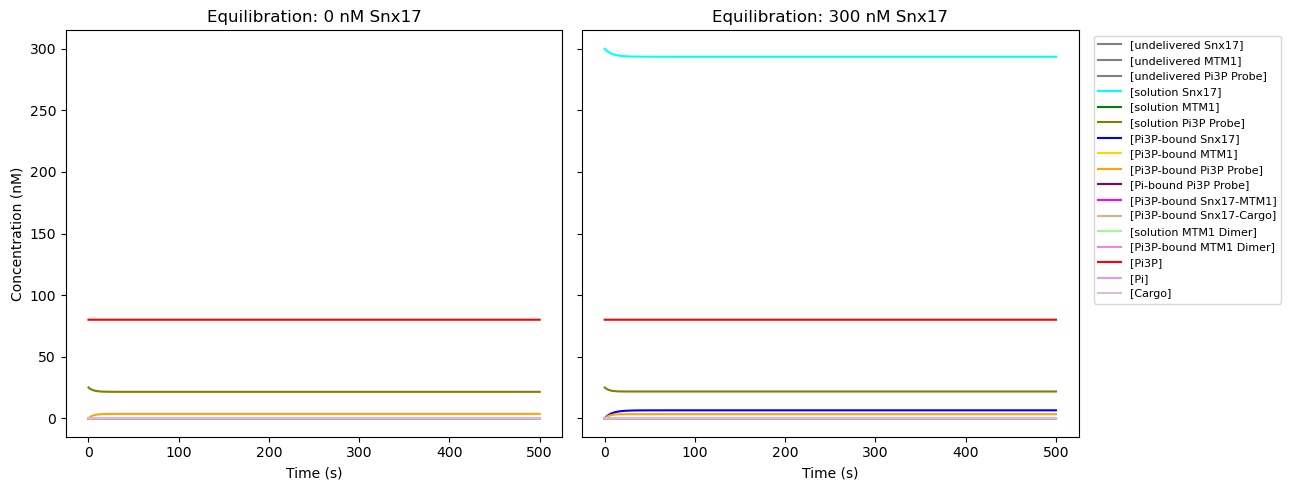

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, dose, result in zip(axes, [0, 300], [sol_eq_0, sol_eq_300]):
    for i, name in enumerate(label_list):
        ax.plot(result.t, result.y[i], label=name, color=colour_list[i])
    ax.set(title=f"Equilibration: {dose} nM Snx17", xlabel="Time (s)")
axes[0].set_ylabel("Concentration (nM)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## 11. Plot assay curves and the areas being compared

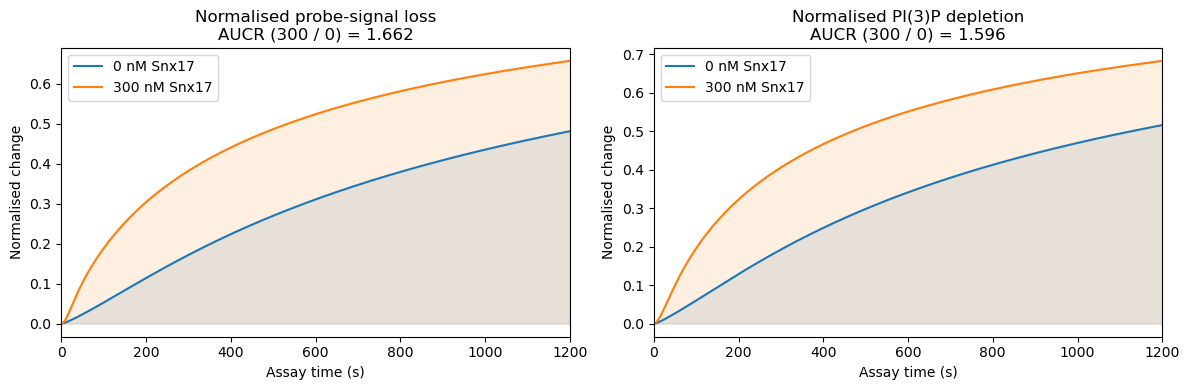

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["Normalised probe-signal loss", "Normalised PI(3)P depletion"]):
    for dose, color in [(0, "tab:blue"), (300, "tab:orange")]:
        t, values = runs[dose].t, curves[dose][metric]
        ax.plot(t, values, color=color, label=f"{dose} nM Snx17")
        ax.fill_between(t, 0, values, color=color, alpha=0.12)
    ratio = auc_summary.loc[auc_summary["Curve"] == metric, "AUCR (300 / 0)"].iloc[0]
    ax.set(title=f"{metric}\nAUCR (300 / 0) = {ratio:.3f}",
           xlabel="Assay time (s)", ylabel="Normalised change", xlim=simulation_time)
    ax.legend()
fig.tight_layout()
plt.show()

## 12. Plot membrane-bound MTM1

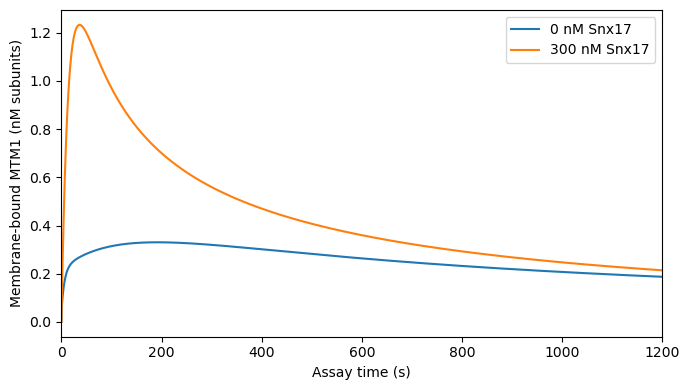

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for dose, result in runs.items():
    bound_mtm1 = result.y[7] + result.y[10] + 2 * result.y[13]
    ax.plot(result.t, bound_mtm1, label=f"{dose} nM Snx17")
ax.set(xlabel="Assay time (s)", ylabel="Membrane-bound MTM1 (nM subunits)",
       xlim=simulation_time)
ax.legend()
fig.tight_layout()
plt.show()

## 13. Optional experimental overlay (excluded from AUC calculations)

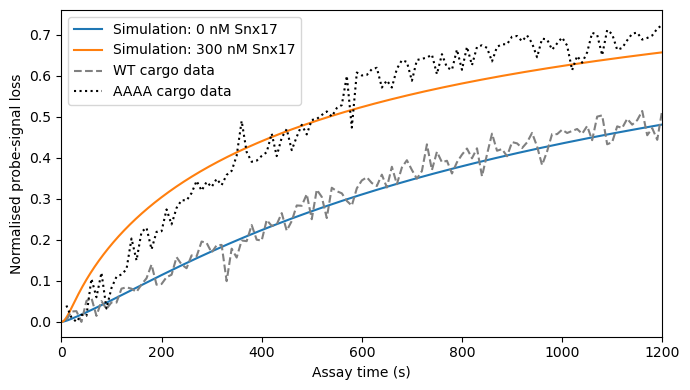

In [13]:
if experimental_csv.is_file():
    df = pd.read_csv(experimental_csv)
    df_time = df[file_settings["time_column"]] * file_settings["time_to_seconds"]
    fig, ax = plt.subplots(figsize=(7, 4))
    for dose, result in runs.items():
        ax.plot(result.t, curves[dose]["Normalised probe-signal loss"],
                label=f"Simulation: {dose} nM Snx17")
    ax.plot(df_time, df[file_settings["WT_column"]], "--", color="grey", label="WT cargo data")
    ax.plot(df_time, df[file_settings["AAAA_column"]], ":", color="black", label="AAAA cargo data")
    ax.set(xlabel="Assay time (s)", ylabel="Normalised probe-signal loss", xlim=simulation_time)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print(f"Optional experimental overlay skipped: {experimental_csv.name} not found.")
# WT/AAAA cargo data are not automatically matched to the Snx17 scenarios.

## 14. Export both trajectories and the AUC comparison

In [14]:
# Distinct filenames preserve both runs; the YAML supplies the base output name.
for dose, result in runs.items():
    output = results_csv.with_name(f"{results_csv.stem}_Snx17_{dose}nM.csv")
    table = pd.DataFrame({"time_s": result.t,
                          "Snx17_at_equilibration_nM": dose})
    for i, name in enumerate(label_list):
        table[name + " (nM)"] = result.y[i]
    for metric, values in curves[dose].items():
        table[metric] = values
    table.to_csv(output, index=False)
    print(f"Saved {output.name}")
summary_path = results_csv.with_name(f"{results_csv.stem}_AUC_comparison.csv")
auc_summary.to_csv(summary_path, index=False)
print(f"Saved {summary_path.name}")

Saved results_Snx17_0nM.csv
Saved results_Snx17_300nM.csv
Saved results_AUC_comparison.csv


## 15. Sensitivity-analysis settings and helper functions

One-at-a-time analysis: each of the 8 affinities, 3 catalytic coefficients, and `membrane_substrate` is set to **0.5× and 2×** its baseline value. All other inputs are held fixed. Both scenarios are independently re-equilibrated for every change, followed by their assays. AUC uses the `primary_metric` selected above (normalised probe-signal loss by default), with AUCR = 300 / 0.

`null` catalytic coefficients are first resolved to their baseline numerical values. They are then varied **independently**: changing `keff_M` here does not also change `keff_SM` or `keff_MM`. Affinity changes update their dependent dissociation rates using the existing reference formulas. Higher Kd means weaker binding.

For speed, sensitivity runs use LSODA with tighter tolerances and a common 1-second output grid. A baseline check against the main assay AUCs must pass within 0.1% before the sweep runs. The three plots show percentage changes from the sensitivity baseline and state its absolute value. A zero baseline cannot be varied multiplicatively, so this analysis requires positive tested values.

In [15]:
from copy import deepcopy

SA_FACTORS = (0.5, 2.0)
SA_OUTPUT_STEP_S = 1.0
SA_SOLVER = {"method": "LSODA", "rtol": 1e-7, "atol": 1e-9}
SA_BASELINE_RTOL = 0.001

sa_config = deepcopy(config)
# Freeze inherited catalytic values before varying each coefficient separately.
for name in ("keff_SM", "keff_MM"):
    if sa_config["catalysis"][name] is None:
        sa_config["catalysis"][name] = sa_config["catalysis"]["keff_M"]
sa_targets = [("affinities", name) for name in sa_config["affinities"]]
sa_targets += [("catalysis", name) for name in ("keff_M", "keff_SM", "keff_MM")]
sa_targets += [("membrane", "membrane_substrate")]
for section, name in sa_targets:
    if not np.isfinite(sa_config[section][name]) or sa_config[section][name] <= 0:
        raise ValueError(f"{name} must be positive for a fold-change analysis.")
if 2 * sa_config["membrane"]["membrane_substrate"] + sa_config["membrane"]["membrane_product"] > 1:
    raise ValueError("Doubling membrane_substrate would make substrate + product fractions exceed 1.")

def sensitivity_parameters(config):
    affinities = config["affinities"]
    Volume = config["geometry"]["Volume"]
    TotalMembraneSA = config["geometry"]["TotalMembraneSA"]
    
    keff_M = config["catalysis"]["keff_M"]
    keff_SM = config["catalysis"]["keff_SM"]
    keff_MM = config["catalysis"]["keff_MM"]
    if keff_SM is None:
        keff_SM = keff_M
    if keff_MM is None:
        keff_MM = keff_M
    
    params = dict(config["association_rates"])
    ref = config["dissociation_reference"]
    for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                            ("PA", "Kd_PA"), ("PB", "Kd_PB"),
                            ("MMf", "Kd_MM_3D")]:
        reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
        params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])
    for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC"), ("MMa", "Kd_MM_2D")]:
        params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])
    
    divisors = config["complex_off_rate_divisors"]
    params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
    params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
    params["koff_MAM"] = params["koff_MA"] / divisors["MAM"]
    params.update(keff_M=keff_M, keff_SM=keff_SM, keff_MM=keff_MM,
                  ka=config["transport"]["ka"])
    
    return params, Volume, TotalMembraneSA

def sensitivity_pair(settings):
    local_params, volume, area = sensitivity_parameters(settings)
    eq = settings["equilibration"]
    assay = settings["assay"]
    mem = settings["membrane"]
    times = np.linspace(assay["time_s"][0], assay["time_s"][1],
                        int(np.ceil((assay["time_s"][1] - assay["time_s"][0]) / SA_OUTPUT_STEP_S)) + 1)
    aucs = {}
    for dose in (0, 300):
        y0 = np.zeros(17)
        y0[3:6] = [dose, eq["MTM1_conc"], eq["Probe_conc"]]
        y0[14:17] = [mem["PC_concentration"] * mem["membrane_substrate"],
                     mem["PC_concentration"] * mem["membrane_product"],
                     mem["PC_concentration"] * eq["cargo_fraction"]]
        eq_result = solve_ivp(model, eq["time_s"], y0,
                              args=(local_params, volume, area), **SA_SOLVER)
        if not eq_result.success:
            raise RuntimeError(eq_result.message)
        assay_y0 = eq_result.y[:, -1].copy()
        assay_y0[3:6] += [assay["Snx17_conc"], assay["MTM1_conc"], assay["Probe_conc"]]
        result = solve_ivp(model, assay["time_s"], assay_y0, t_eval=times,
                           args=(local_params, volume, area), **SA_SOLVER)
        if not result.success:
            raise RuntimeError(result.message)
        available_curves = {
            "Normalised probe-signal loss": normalised_loss(result.y[8]),
            "Normalised PI(3)P depletion": normalised_loss(result.y[14]),
            "Bound PI(3)P probe": result.y[8],
            "Total PI(3)P": result.y[14],
        }
        aucs[dose] = calculate_auc(result.t, available_curves[primary_metric])
    if not all(np.isfinite(v) and v > 1e-12 for v in aucs.values()):
        raise ValueError("Sensitivity comparison requires finite, positive AUCs.")
    return {"AUC_MTM1_only": aucs[0], "AUC_MTM1_Snx17": aucs[300],
            "AUCR": aucs[300] / aucs[0]}

## 16. Execute sensitivity analysis (no plotting)

In [16]:
sa_baseline = sensitivity_pair(sa_config)
main_row = auc_summary.loc[auc_summary["Curve"] == primary_metric].iloc[0]
for key, main_column in [("AUC_MTM1_only", "AUC (0 nM Snx17)"),
                          ("AUC_MTM1_Snx17", "AUC (300 nM Snx17)"),
                          ("AUCR", "AUCR (300 / 0)")]:
    if not np.isclose(sa_baseline[key], main_row[main_column], rtol=SA_BASELINE_RTOL, atol=1e-8):
        raise RuntimeError("Sensitivity baseline differs from the main runs. Restart and Run All; "
                           "if it persists, refine the solver/output settings before comparing.")
print("Baseline agreement check passed.", flush=True)
sa_records = []
for section, name in sa_targets:
    baseline_value = sa_config[section][name]
    for factor in SA_FACTORS:
        perturbed = deepcopy(sa_config)
        perturbed[section][name] = baseline_value * factor
        result = sensitivity_pair(perturbed)
        record = {"parameter": name, "section": section, "factor": factor,
                  "baseline_parameter": baseline_value,
                  "tested_parameter": baseline_value * factor,
                  "curve": primary_metric, **result}
        for metric, baseline in sa_baseline.items():
            record[metric + "_baseline"] = baseline
            record[metric + "_change_percent"] = 100 * (result[metric] / baseline - 1)
        sa_records.append(record)
    print(f"Completed {name}: 0.5x and 2x", flush=True)
sa_results = pd.DataFrame(sa_records)
print(sa_results[["parameter", "factor", "AUC_MTM1_only", "AUC_MTM1_Snx17", "AUCR"]]
      .to_string(index=False, float_format=lambda x: f"{x:.6g}"))

Baseline agreement check passed.
Completed Kd_SA: 0.5x and 2x
Completed Kd_MA: 0.5x and 2x
Completed Kd_PA: 0.5x and 2x
Completed Kd_PB: 0.5x and 2x
Completed Kd_SM: 0.5x and 2x
Completed Kd_SC: 0.5x and 2x
Completed Kd_MM_2D: 0.5x and 2x
Completed Kd_MM_3D: 0.5x and 2x
Completed keff_M: 0.5x and 2x
Completed keff_SM: 0.5x and 2x
Completed keff_MM: 0.5x and 2x
Completed membrane_substrate: 0.5x and 2x
         parameter  factor  AUC_MTM1_only  AUC_MTM1_Snx17    AUCR
             Kd_SA     0.5        341.085         636.211 1.86526
             Kd_SA       2        341.085         492.471 1.44384
             Kd_MA     0.5        553.179         692.685 1.25219
             Kd_MA       2        187.301         433.414   2.314
             Kd_PA     0.5        299.318         515.821 1.72332
             Kd_PA       2        367.733         597.237  1.6241
             Kd_PB     0.5        341.448         567.301 1.66146
             Kd_PB       2        340.903         566.641 1.66218
 

## 17. Plot sensitivity: three separate figures

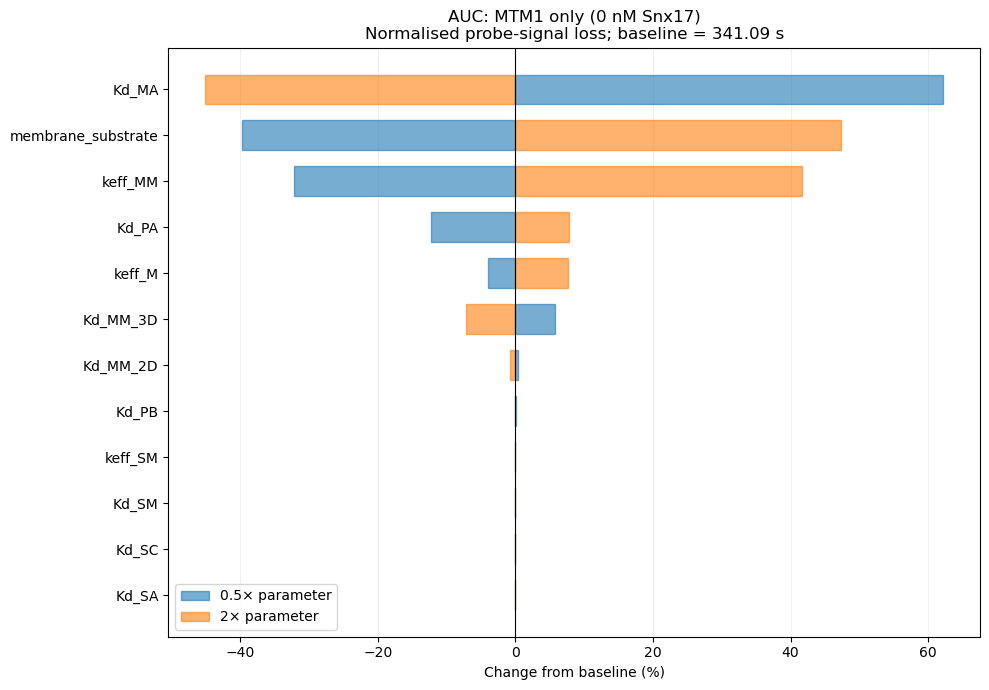

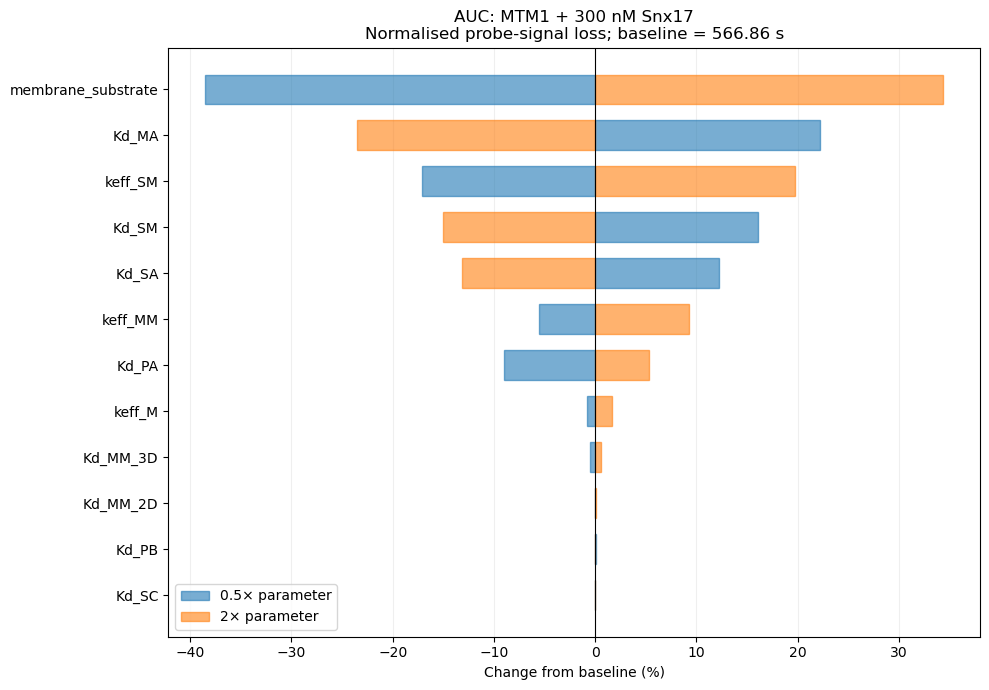

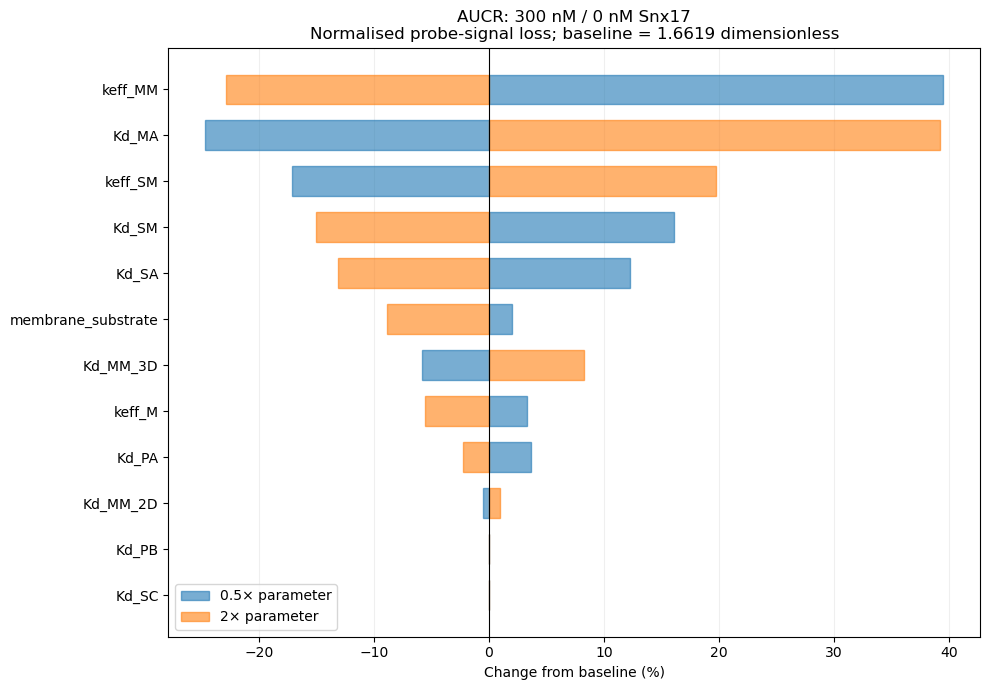

In [17]:
# One shared row per parameter; transparency keeps overlapping bars visible.
# Each figure is sorted by its own largest absolute percentage change.
auc_units = main_row["AUC units"]
for metric, title, unit in [
    ("AUC_MTM1_only", "AUC: MTM1 only (0 nM Snx17)", auc_units),
    ("AUC_MTM1_Snx17", "AUC: MTM1 + 300 nM Snx17", auc_units),
    ("AUCR", "AUCR: 300 nM / 0 nM Snx17", "dimensionless"),
]:
    column = metric + "_change_percent"
    ranked = sa_results.groupby("parameter")[column].apply(lambda v: v.abs().max()).sort_values()
    names = ranked.index.tolist()
    y = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(10, 7))
    for factor, color in [(0.5, "tab:blue"), (2.0, "tab:orange")]:
        values = sa_results[sa_results["factor"] == factor].set_index("parameter").loc[names, column]
        ax.barh(y, values, height=0.65, color=color, alpha=0.6,
                edgecolor=color, linewidth=1, label=f"{factor:g}× parameter")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y, labels=names)
    ax.set_xlabel("Change from baseline (%)")
    ax.set_title(f"{title}\n{primary_metric}; baseline = {sa_baseline[metric]:.5g} {unit}")
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend()
    fig.tight_layout()
    plt.show()

## 18. Export sensitivity results

In [18]:
sa_output = results_csv.with_name(f"{results_csv.stem}_sensitivity.csv")
sa_results.to_csv(sa_output, index=False)
print(f"Saved {sa_output.name}")

Saved results_sensitivity.csv
